# Notebook 04: Train and Evaluate YOLO Models

## Objective
Train and evaluate **4 models**:
1. **COCO Pretrained (Baseline)** - No additional training - baseline comparison
2. **Real-Only 8262** - Trained on 8,262 real images
3. **Real-Only 4131** - Trained on 4,131 real images (fair comparison to Mixed model)
4. **Mixed** - Trained on 4,131 real + 4,131 synthetic images

## Evaluation
Each model is evaluated on 3 test sets:
- Real Test (1,547 images)
- Synthetic Test (1,547 images)
- Mixed Test (3,094 images)

## Metrics
- mAP@0.5
- mAP@0.5:0.95
- Precision, Recall, F1
- **Per-class metrics**

---

## 1. Setup and Imports

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install ultralytics if needed
!pip install -q ultralytics

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
import torch

# Check GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA L4
GPU Memory: 23.8 GB


In [ ]:
# === CONFIGURATION ===

# Paths
BASE_PATH = Path('/content/drive/MyDrive/StormVision')
DATA_PATH = BASE_PATH / 'data'
PROCESSED = DATA_PATH / 'processed'
RESULTS_PATH = BASE_PATH / 'results'

# Create results directories
WEIGHTS_PATH = RESULTS_PATH / 'weights'
METRICS_PATH = RESULTS_PATH / 'metrics'
PREDICTIONS_PATH = RESULTS_PATH / 'predictions'

for p in [WEIGHTS_PATH, METRICS_PATH, PREDICTIONS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

# Model configuration
MODEL_NAME = 'yolov8s.pt'  # YOLOv8 Small
IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 25
PATIENCE = 5  # Early stopping patience
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5

# Class names
CLASS_NAMES = ['swimmer', 'boat', 'jetski', 'life_saving_appliances', 'buoy']

# Data yaml files
YAML_REAL = PROCESSED / 'yolo_real.yaml'
YAML_MIXED = PROCESSED / 'yolo_mixed.yaml'
YAML_REAL_4131 = PROCESSED / 'yolo_real_4131.yaml'

# Test split files
TEST_REAL = PROCESSED / 'splits' / 'test_real.txt'
TEST_SYNTHETIC = PROCESSED / 'splits' / 'test_synthetic.txt'
TEST_MIXED = PROCESSED / 'splits' / 'test_mixed.txt'

print("Configuration:")
print(f"  Model: {MODEL_NAME}")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS} (patience={PATIENCE})")
print(f"  Results: {RESULTS_PATH}")

Configuration:
  Model: yolov8s.pt
  Image size: 640
  Batch size: 16
  Epochs: 25 (patience=5)
  Results: /content/drive/MyDrive/StormVision/results


In [ ]:
# Verify all required files exist
files_to_check = [
    ('YAML Real', YAML_REAL),
    ('YAML Mixed', YAML_MIXED),
    ('YAML Real 4131', YAML_REAL_4131),
    ('Test Real', TEST_REAL),
    ('Test Synthetic', TEST_SYNTHETIC),
    ('Test Mixed', TEST_MIXED),
]

print("Checking required files:")
all_ok = True
for name, path in files_to_check:
    exists = path.exists()
    status = "[OK]" if exists else "[MISSING]"
    print(f"  {status} {name}: {path}")
    if not exists:
        all_ok = False

if not all_ok:
    print("\nWARNING: Missing files! Run preparation notebook first.")
else:
    print("\nAll files found!")

Checking required files:
  [OK] YAML Real: /content/drive/MyDrive/StormVision/data/processed/yolo_real.yaml
  [OK] YAML Mixed: /content/drive/MyDrive/StormVision/data/processed/yolo_mixed.yaml
  [OK] YAML Real 4131: /content/drive/MyDrive/StormVision/data/processed/yolo_real_4131.yaml
  [OK] Test Real: /content/drive/MyDrive/StormVision/data/processed/splits/test_real.txt
  [OK] Test Synthetic: /content/drive/MyDrive/StormVision/data/processed/splits/test_synthetic.txt
  [OK] Test Mixed: /content/drive/MyDrive/StormVision/data/processed/splits/test_mixed.txt

All files found!


## 2. Helper Functions

In [ ]:
def create_eval_yaml(test_split_path, yaml_name):
    """Create a YAML file for evaluation on a specific test set."""
    yaml_content = f"""path: {DATA_PATH}
train: processed/splits/train_real_only.txt
val: {test_split_path}

names:
  0: swimmer
  1: boat
  2: jetski
  3: life_saving_appliances
  4: buoy
"""
    yaml_path = PROCESSED / yaml_name
    yaml_path.write_text(yaml_content)
    return yaml_path

# Create evaluation YAMLs
EVAL_YAML_REAL = create_eval_yaml('processed/splits/test_real.txt', 'eval_test_real.yaml')
EVAL_YAML_SYNTH = create_eval_yaml('processed/splits/test_synthetic.txt', 'eval_test_synth.yaml')
EVAL_YAML_MIXED = create_eval_yaml('processed/splits/test_mixed.txt', 'eval_test_mixed.yaml')

print("Created evaluation YAMLs:")
print(f"  {EVAL_YAML_REAL}")
print(f"  {EVAL_YAML_SYNTH}")
print(f"  {EVAL_YAML_MIXED}")

Created evaluation YAMLs:
  /content/drive/MyDrive/StormVision/data/processed/eval_test_real.yaml
  /content/drive/MyDrive/StormVision/data/processed/eval_test_synth.yaml
  /content/drive/MyDrive/StormVision/data/processed/eval_test_mixed.yaml


In [ ]:
def evaluate_model_comprehensive(model, eval_yaml, model_name, test_set_name):
    """
    Evaluate a model and return comprehensive metrics including per-class.
    """
    print(f"  Evaluating {model_name} on {test_set_name}...")

    try:
        results = model.val(data=str(eval_yaml), verbose=False)

        # Overall metrics
        metrics = {
            'model': model_name,
            'test_set': test_set_name,
            'mAP50': float(results.box.map50),
            'mAP50-95': float(results.box.map),
            'precision': float(results.box.mp),
            'recall': float(results.box.mr),
        }

        # Calculate F1
        p, r = metrics['precision'], metrics['recall']
        metrics['F1'] = 2 * (p * r) / (p + r + 1e-6)

        # Per-class metrics
        for i, cls_name in enumerate(CLASS_NAMES):
            if i < len(results.box.ap50):
                metrics[f'AP50_{cls_name}'] = float(results.box.ap50[i])
                metrics[f'AP_{cls_name}'] = float(results.box.ap[i])

        print(f"    mAP50: {metrics['mAP50']:.4f}, F1: {metrics['F1']:.4f}")
        return metrics

    except Exception as e:
        print(f"    Error: {e}")
        return None

## 3. Model Training

### 3.1 Model 1: Real-Only 8262 (Original)

In [ ]:
print("="*60)
print("MODEL 1: Real-Only 8262 Images")
print("="*60)

model_real_path = WEIGHTS_PATH / 'model_real' / 'weights' / 'best.pt'

if model_real_path.exists():
    print(f"[OK] Found existing model: {model_real_path}")
    print("     Loading instead of retraining...")
    model_real = YOLO(str(model_real_path))
else:
    print(f"Training new model...")
    print(f"  Data: {YAML_REAL}")
    print(f"  Epochs: {EPOCHS}")

    model_real = YOLO(MODEL_NAME)
    results_real = model_real.train(
        data=str(YAML_REAL),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        project=str(WEIGHTS_PATH),
        name='model_real',
        exist_ok=True,
        verbose=True,
        plots=True
    )
    print(f"[OK] Training complete!")

MODEL 1: Real-Only 8262 Images
[OK] Found existing model: /content/drive/MyDrive/StormVision/results/weights/model_real/weights/best.pt
     Loading instead of retraining...


### 3.2 Model 2: Real-Only 4131 (Fair Comparison)

In [ ]:
print("="*60)
print("MODEL 2: Real-Only 4131 Images (Fair Comparison)")
print("="*60)

model_real_4131_path = WEIGHTS_PATH / 'model_real_4131' / 'weights' / 'best.pt'

if model_real_4131_path.exists():
    print(f"[OK] Found existing model: {model_real_4131_path}")
    print("     Loading instead of retraining...")
    model_real_4131 = YOLO(str(model_real_4131_path))
else:
    print(f"Training new model...")
    print(f"  Data: {YAML_REAL_4131}")
    print(f"  Epochs: {EPOCHS}")

    model_real_4131 = YOLO(MODEL_NAME)
    results_real_4131 = model_real_4131.train(
        data=str(YAML_REAL_4131),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        project=str(WEIGHTS_PATH),
        name='model_real_4131',
        exist_ok=True,
        verbose=True,
        plots=True
    )
    print(f"[OK] Training complete!")

MODEL 2: Real-Only 4131 Images (Fair Comparison)
[OK] Found existing model: /content/drive/MyDrive/StormVision/results/weights/model_real_4131/weights/best.pt
     Loading instead of retraining...


### 3.3 Model 3: Mixed (Real + Synthetic)

In [ ]:
print("="*60)
print("MODEL 3: Mixed (4131 Real + 4131 Synthetic)")
print("="*60)

model_mixed_path = WEIGHTS_PATH / 'model_mixed' / 'weights' / 'best.pt'

if model_mixed_path.exists():
    print(f"[OK] Found existing model: {model_mixed_path}")
    print("     Loading instead of retraining...")
    model_mixed = YOLO(str(model_mixed_path))
else:
    print(f"Training new model...")
    print(f"  Data: {YAML_MIXED}")
    print(f"  Epochs: {EPOCHS}")

    model_mixed = YOLO(MODEL_NAME)
    results_mixed = model_mixed.train(
        data=str(YAML_MIXED),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        project=str(WEIGHTS_PATH),
        name='model_mixed',
        exist_ok=True,
        verbose=True,
        plots=True
    )
    print(f"[OK] Training complete!")

MODEL 3: Mixed (4131 Real + 4131 Synthetic)
[OK] Found existing model: /content/drive/MyDrive/StormVision/results/weights/model_mixed/weights/best.pt
     Loading instead of retraining...


## 4. Comprehensive Evaluation

In [ ]:
print("="*60)
print("COMPREHENSIVE EVALUATION")
print("="*60)

# Load all models
models = {}

# COCO Pretrained
print("\nLoading models...")
models['COCO_Pretrained'] = YOLO('yolov8s.pt')
print("  [OK] COCO_Pretrained (baseline)")

# Real 8262
if model_real_path.exists():
    models['Real_8262'] = YOLO(str(model_real_path))
    print("  [OK] Real_8262")

# Real 4131
if model_real_4131_path.exists():
    models['Real_4131'] = YOLO(str(model_real_4131_path))
    print("  [OK] Real_4131")

# Mixed
if model_mixed_path.exists():
    models['Mixed'] = YOLO(str(model_mixed_path))
    print("  [OK] Mixed")

print(f"\nTotal models: {len(models)}")

COMPREHENSIVE EVALUATION

Loading models...
  [OK] COCO_Pretrained (baseline)
  [OK] Real_8262
  [OK] Real_4131
  [OK] Mixed

Total models: 4


In [ ]:
# Evaluate all models on all test sets
all_results = []

test_sets = {
    'Real': EVAL_YAML_REAL,
    'Synthetic': EVAL_YAML_SYNTH,
    'Mixed': EVAL_YAML_MIXED
}

for model_name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Evaluating: {model_name}")
    print('='*40)

    for test_set_name, eval_yaml in test_sets.items():
        result = evaluate_model_comprehensive(model, eval_yaml, model_name, test_set_name)
        if result:
            all_results.append(result)

# Create DataFrame
df_results = pd.DataFrame(all_results)
print(f"\n[OK] Evaluation complete! {len(all_results)} results.")

## 5. Results Summary

In [ ]:
#  Load results from saved CSV (skip evaluation)


csv_path = METRICS_PATH / 'comprehensive_results.csv'

if csv_path.exists():
    print("Loading results from saved CSV...")
    df_results = pd.read_csv(csv_path)
    print(f"[OK] Loaded {len(df_results)} results from: {csv_path}")
else:
    print("CSV not found! Run evaluation first.")

Loading results from saved CSV...
[OK] Loaded 12 results from: /content/drive/MyDrive/StormVision/results/metrics/comprehensive_results.csv


In [ ]:
from IPython.display import display, HTML
# Display main metrics
print("="*80)
print("                         RESULTS SUMMARY")
print("="*80)


# Create styled DataFrame
styled_df = df_results[['model', 'test_set', 'mAP50', 'mAP50-95', 'precision', 'recall', 'F1']].copy()
styled_df = styled_df.round(3)

# Display as styled table
display(styled_df.style.background_gradient(cmap='RdYlGn', subset=['mAP50', 'mAP50-95', 'F1']))

                         RESULTS SUMMARY


,model,test_set,mAP50,mAP50-95,precision,recall,F1
0,COCO_Pretrained,Real,0.073000,0.038000,0.089000,0.143000,0.109000
1,COCO_Pretrained,Synthetic,0.066000,0.032000,0.083000,0.082000,0.082000
2,COCO_Pretrained,Mixed,0.069000,0.034000,0.084000,0.137000,0.104000
3,Real_8262,Real,0.708000,0.415000,0.833000,0.674000,0.745000
4,Real_8262,Synthetic,0.491000,0.269000,0.763000,0.467000,0.580000
5,Real_8262,Mixed,0.604000,0.343000,0.784000,0.564000,0.656000
6,Real_4131,Real,0.687000,0.396000,0.823000,0.647000,0.725000
7,Real_4131,Synthetic,0.493000,0.265000,0.585000,0.455000,0.512000
8,Real_4131,Mixed,0.593000,0.331000,0.774000,0.554000,0.646000
9,Mixed,Real,0.709000,0.417000,0.851000,0.674000,0.752000


In [ ]:
# Save results
csv_path = METRICS_PATH / 'comprehensive_results.csv'
df_results.to_csv(csv_path, index=False)
print(f"\n[OK] Results saved to: {csv_path}")

## 6. Visualization

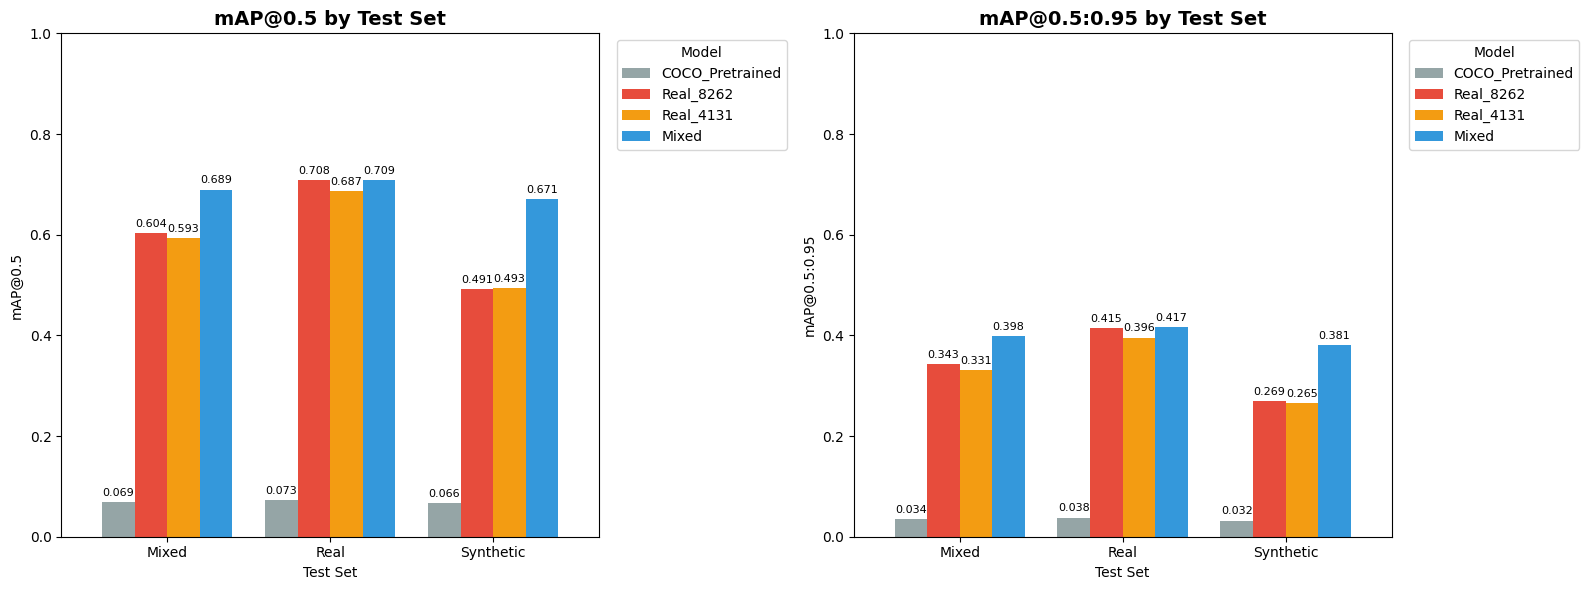


[OK] Chart saved to: /content/drive/MyDrive/StormVision/results/metrics/model_comparison.png


In [ ]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors for each model
colors = ['#95a5a6', '#e74c3c', '#f39c12', '#3498db']  # Gray, Red, Orange, Blue

# Get available models in order
model_order = [m for m in ['COCO_Pretrained', 'Real_8262', 'Real_4131', 'Mixed'] if m in df_results['model'].values]

# Plot 1: mAP@0.5
ax1 = axes[0]
pivot_map50 = df_results.pivot(index='test_set', columns='model', values='mAP50')
pivot_map50 = pivot_map50[model_order]
pivot_map50.plot(kind='bar', ax=ax1, color=colors[:len(model_order)], width=0.8)
ax1.set_title('mAP@0.5 by Test Set', fontsize=14, fontweight='bold')
ax1.set_xlabel('Test Set')
ax1.set_ylabel('mAP@0.5')
ax1.set_ylim(0, 1)
ax1.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=0)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

# Plot 2: mAP@0.5:0.95
ax2 = axes[1]
pivot_map = df_results.pivot(index='test_set', columns='model', values='mAP50-95')
pivot_map = pivot_map[model_order]
pivot_map.plot(kind='bar', ax=ax2, color=colors[:len(model_order)], width=0.8)
ax2.set_title('mAP@0.5:0.95 by Test Set', fontsize=14, fontweight='bold')
ax2.set_xlabel('Test Set')
ax2.set_ylabel('mAP@0.5:0.95')
ax2.set_ylim(0, 1)
ax2.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(METRICS_PATH / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[OK] Chart saved to: {METRICS_PATH / 'model_comparison.png'}")

                    F1 SCORE COMPARISON


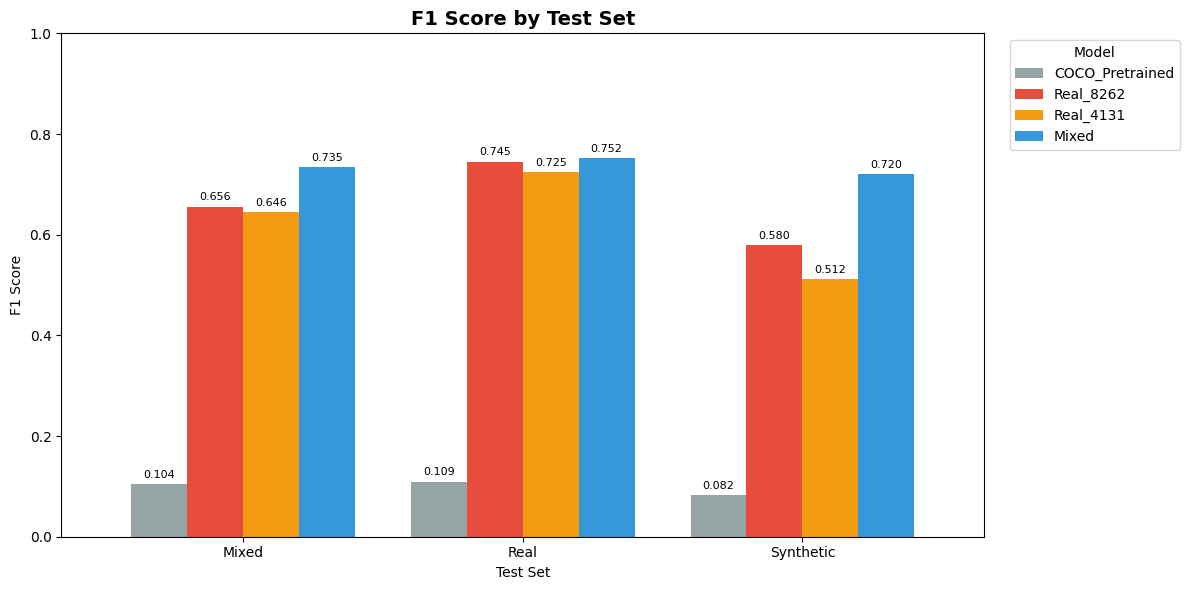


[OK] Saved to: /content/drive/MyDrive/StormVision/results/metrics/f1_comparison.png


In [ ]:
# F1 SCORE COMPARISON
print("="*80)
print("                    F1 SCORE COMPARISON")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_f1 = df_results.pivot(index='test_set', columns='model', values='F1')
pivot_f1 = pivot_f1[model_order]
pivot_f1.plot(kind='bar', ax=ax, color=colors[:len(model_order)], width=0.8)
ax.set_title('F1 Score by Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Set')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(METRICS_PATH / 'f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[OK] Saved to: {METRICS_PATH / 'f1_comparison.png'}")

           ROBUSTNESS ANALYSIS: Performance Degradation

Performance Drop Table:


,Model,Real_mAP50,Synthetic_mAP50,Performance_Drop,Drop_Percent
0,Real_8262,0.708,0.491,0.217,30.646
1,Real_4131,0.687,0.493,0.194,28.235
2,Mixed,0.709,0.671,0.038,5.361


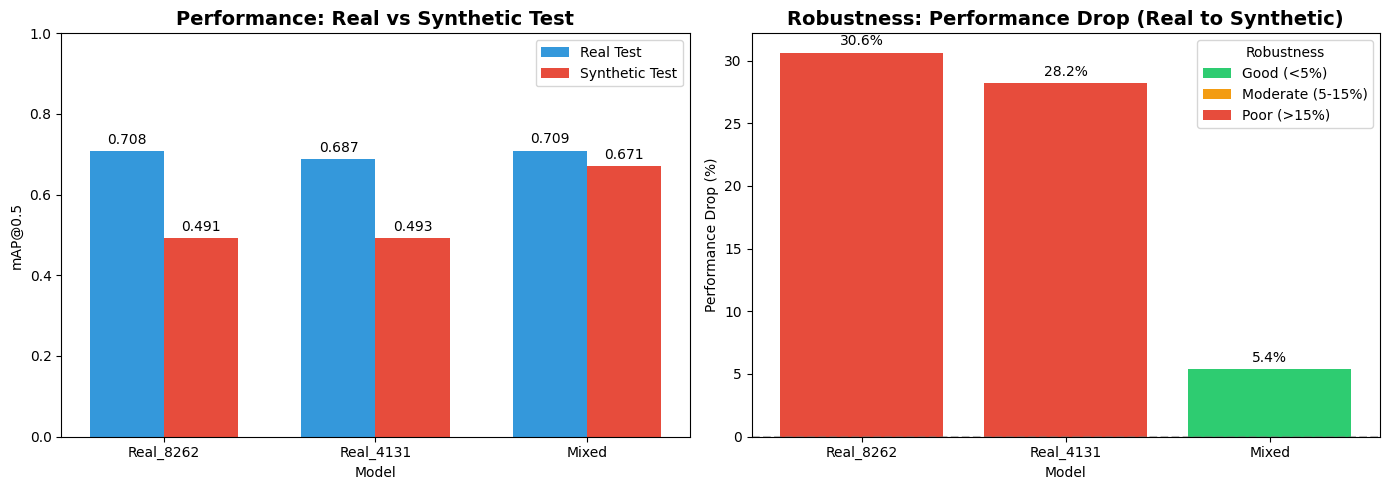


[OK] Saved to: /content/drive/MyDrive/StormVision/results/metrics/robustness_analysis.png


In [ ]:
# ROBUSTNESS ANALYSIS: Performance Drop from Real to Synthetic
print("="*80)
print("           ROBUSTNESS ANALYSIS: Performance Degradation")
print("="*80)

# Calculate performance drop for each model
robustness_data = []

for model_name in ['Real_8262', 'Real_4131', 'Mixed']:
    real_perf = df_results[(df_results['model'] == model_name) & (df_results['test_set'] == 'Real')]['mAP50'].values
    synth_perf = df_results[(df_results['model'] == model_name) & (df_results['test_set'] == 'Synthetic')]['mAP50'].values

    if len(real_perf) > 0 and len(synth_perf) > 0:
        drop = real_perf[0] - synth_perf[0]
        drop_pct = (drop / real_perf[0]) * 100
        robustness_data.append({
            'Model': model_name,
            'Real_mAP50': real_perf[0],
            'Synthetic_mAP50': synth_perf[0],
            'Performance_Drop': drop,
            'Drop_Percent': drop_pct
        })

robustness_df = pd.DataFrame(robustness_data)
print("\nPerformance Drop Table:")
display(robustness_df.round(3))

# Robustness Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Grouped bar chart (Real vs Synthetic performance)
ax1 = axes[0]
x = np.arange(len(robustness_df))
width = 0.35

bars1 = ax1.bar(x - width/2, robustness_df['Real_mAP50'], width, label='Real Test', color='#3498db')
bars2 = ax1.bar(x + width/2, robustness_df['Synthetic_mAP50'], width, label='Synthetic Test', color='#e74c3c')

ax1.set_xlabel('Model')
ax1.set_ylabel('mAP@0.5')
ax1.set_title('Performance: Real vs Synthetic Test', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(robustness_df['Model'])
ax1.legend()
ax1.set_ylim(0, 1)
ax1.bar_label(bars1, fmt='%.3f', padding=3)
ax1.bar_label(bars2, fmt='%.3f', padding=3)

# Right: Performance Drop (Robustness)
ax2 = axes[1]
colors = ['#e74c3c' if d > 0.15 else '#f39c12' if d > 0.05 else '#2ecc71' for d in robustness_df['Performance_Drop']]
bars = ax2.bar(robustness_df['Model'], robustness_df['Drop_Percent'], color=colors)
ax2.set_xlabel('Model')
ax2.set_ylabel('Performance Drop (%)')
ax2.set_title('Robustness: Performance Drop (Real to Synthetic)', fontsize=14, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.bar_label(bars, fmt='%.1f%%', padding=3)

# Add color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Good (<5%)'),
    Patch(facecolor='#f39c12', label='Moderate (5-15%)'),
    Patch(facecolor='#e74c3c', label='Poor (>15%)')
]
ax2.legend(handles=legend_elements, loc='upper right', title='Robustness')

plt.tight_layout()
plt.savefig(METRICS_PATH / 'robustness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[OK] Saved to: {METRICS_PATH / 'robustness_analysis.png'}")

       PERFORMANCE DEGRADATION ACROSS TEST CONDITIONS


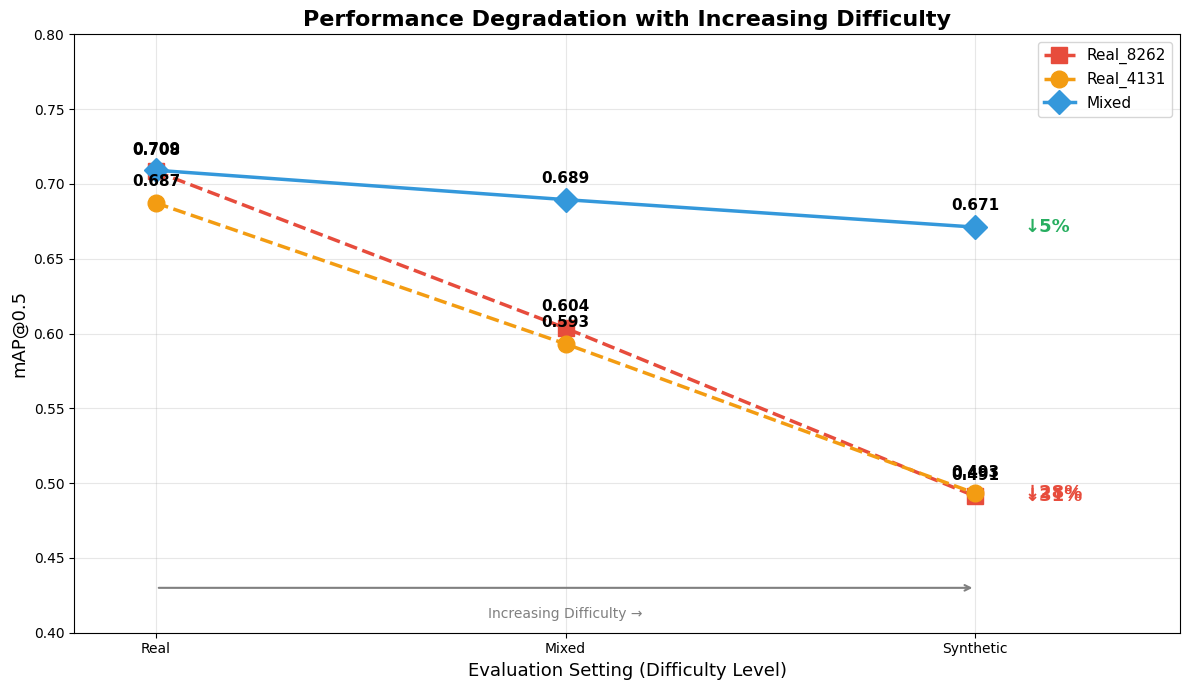


Degradation Summary (Real → Synthetic):
--------------------------------------------------
  Real_8262: 0.708 → 0.491 (↓30.6%)
  Real_4131: 0.687 → 0.493 (↓28.2%)
  Mixed: 0.709 → 0.671 (↓5.4%)

[OK] Saved to: /content/drive/MyDrive/StormVision/results/metrics/performance_degradation.png


In [ ]:
# PERFORMANCE DEGRADATION LINE CHART
print("="*80)
print("       PERFORMANCE DEGRADATION ACROSS TEST CONDITIONS")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 7))

# Test conditions order (easy to hard)
test_order = ['Real', 'Mixed', 'Synthetic']

# Colors and markers for each model
styles = {
    'Real_8262': {'color': '#e74c3c', 'marker': 's', 'linestyle': '--'},
    'Real_4131': {'color': '#f39c12', 'marker': 'o', 'linestyle': '--'},
    'Mixed': {'color': '#3498db', 'marker': 'D', 'linestyle': '-'}
}

# Plot each model
for model_name, style in styles.items():
    y_values = []
    for test_set in test_order:
        val = df_results[(df_results['model'] == model_name) &
                         (df_results['test_set'] == test_set)]['mAP50'].values
        y_values.append(val[0] if len(val) > 0 else np.nan)

    ax.plot(test_order, y_values,
            marker=style['marker'],
            color=style['color'],
            linestyle=style['linestyle'],
            linewidth=2.5,
            markersize=12,
            label=model_name)

    # Add value labels on each point
    for i, (x, y) in enumerate(zip(test_order, y_values)):
        ax.annotate(f'{y:.3f}', (i, y), textcoords="offset points",
                   xytext=(0, 12), ha='center', fontsize=11, fontweight='bold')

    # Calculate and show degradation percentage (Real to Synthetic) - ON THE RIGHT
    if not np.isnan(y_values[0]) and not np.isnan(y_values[2]):
        degradation = ((y_values[0] - y_values[2]) / y_values[0]) * 100
        # Color based on degradation level
        deg_color = '#27ae60' if degradation < 10 else '#f39c12' if degradation < 25 else '#e74c3c'
        # Arrow down symbol
        ax.annotate(f'↓{degradation:.0f}%',
                   xy=(2.12, y_values[2]),
                   fontsize=13, fontweight='bold', color=deg_color,
                   va='center')

ax.set_xlabel('Evaluation Setting (Difficulty Level)', fontsize=13)
ax.set_ylabel('mAP@0.5', fontsize=13)
ax.set_title('Performance Degradation with Increasing Difficulty', fontsize=16, fontweight='bold')
ax.set_ylim(0.4, 0.8)
ax.set_xlim(-0.2, 2.5)  # Extra space on right for percentages
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

# Add arrow showing difficulty direction
ax.annotate('', xy=(2.0, 0.43), xytext=(0, 0.43),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(1, 0.41, 'Increasing Difficulty →', ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(METRICS_PATH / 'performance_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print degradation summary
print("\nDegradation Summary (Real → Synthetic):")
print("-"*50)
for model_name in ['Real_8262', 'Real_4131', 'Mixed']:
    real_val = df_results[(df_results['model'] == model_name) & (df_results['test_set'] == 'Real')]['mAP50'].values[0]
    synth_val = df_results[(df_results['model'] == model_name) & (df_results['test_set'] == 'Synthetic')]['mAP50'].values[0]
    deg = ((real_val - synth_val) / real_val) * 100
    print(f"  {model_name}: {real_val:.3f} → {synth_val:.3f} (↓{deg:.1f}%)")

print(f"\n[OK] Saved to: {METRICS_PATH / 'performance_degradation.png'}")

## 7. Per-Class Analysis

In [ ]:
# Per-Class Results as DataFrame
print("="*80)
print("           PER-CLASS AP@0.5 ON SYNTHETIC TEST SET")
print("="*80)

# Build per-class DataFrame
synth_data = df_results[df_results['test_set'] == 'Synthetic'].copy()

per_class_data = []
for _, row in synth_data.iterrows():
    model_row = {'Model': row['model']}
    for cls_name in CLASS_NAMES:
        col = f'AP50_{cls_name}'
        if col in row and pd.notna(row[col]):
            model_row[cls_name] = row[col]
    per_class_data.append(model_row)

per_class_df = pd.DataFrame(per_class_data)
per_class_df = per_class_df.set_index('Model')
per_class_df = per_class_df.round(3)

# Display styled DataFrame
print("\nPer-Class AP@0.5 on Synthetic Test:")
display(per_class_df.style.background_gradient(cmap='RdYlGn', axis=0, vmin=0, vmax=1))

# Also show improvement from Real_4131 to Mixed
print("\n" + "-"*60)
print("Improvement (Mixed vs Real_4131):")

improvement_row = {}
for cls_name in CLASS_NAMES:
    if cls_name in per_class_df.columns:
        mixed_val = per_class_df.loc['Mixed', cls_name]
        real_val = per_class_df.loc['Real_4131', cls_name]
        improvement = mixed_val - real_val
        pct = (improvement / real_val * 100) if real_val > 0 else 0
        improvement_row[cls_name] = f"+{improvement:.3f} ({pct:+.0f}%)"

improvement_df = pd.DataFrame([improvement_row], index=['Improvement'])
display(improvement_df)

           PER-CLASS AP@0.5 ON SYNTHETIC TEST SET

Per-Class AP@0.5 on Synthetic Test:


,swimmer,boat,jetski,life_saving_appliances,buoy
Model,,,,,
COCO_Pretrained,0.172000,0.138000,0.016000,0.001000,0.004000
Real_8262,0.494000,0.825000,0.686000,0.030000,0.421000
Real_4131,0.504000,0.830000,0.669000,0.038000,0.426000
Mixed,0.697000,0.945000,0.879000,0.187000,0.648000



------------------------------------------------------------
Improvement (Mixed vs Real_4131):


,swimmer,boat,jetski,life_saving_appliances,buoy
Improvement,+0.193 (+38%),+0.115 (+14%),+0.210 (+31%),+0.149 (+392%),+0.222 (+52%)


           PER-CLASS AP@0.5 ON SYNTHETIC TEST SET

Per-Class AP@0.5:


,swimmer,boat,jetski,life_saving_appliances,buoy
Model,,,,,
COCO_Pretrained,0.172,0.138,0.016,0.001,0.004
Real_8262,0.494,0.825,0.686,0.030,0.421
Real_4131,0.504,0.830,0.669,0.038,0.426
Mixed,0.697,0.945,0.879,0.187,0.648


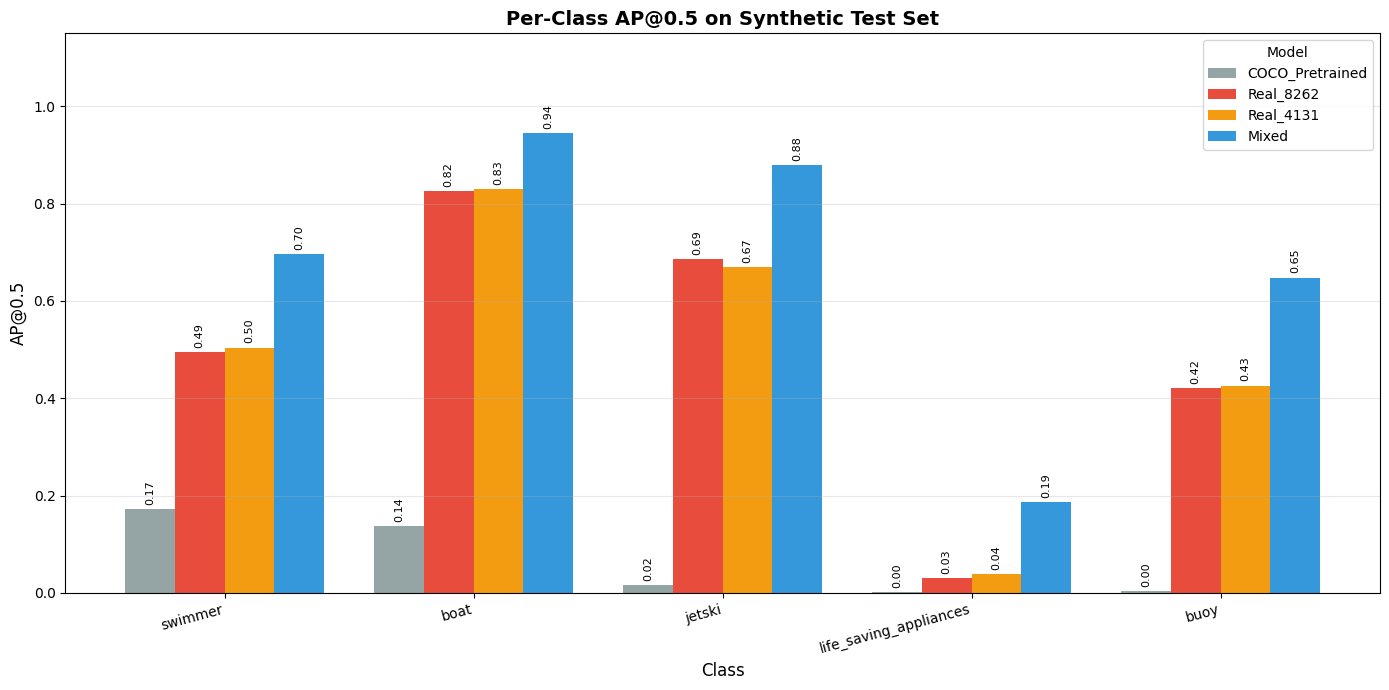


[OK] Bar chart saved to: /content/drive/MyDrive/StormVision/results/metrics/per_class_bar_chart.png


In [ ]:
# Per-Class Bar Chart
print("="*80)
print("           PER-CLASS AP@0.5 ON SYNTHETIC TEST SET")
print("="*80)

# Build per-class DataFrame
synth_data = df_results[df_results['test_set'] == 'Synthetic'].copy()

per_class_data = []
for _, row in synth_data.iterrows():
    model_row = {'Model': row['model']}
    for cls_name in CLASS_NAMES:
        col = f'AP50_{cls_name}'
        if col in row and pd.notna(row[col]):
            model_row[cls_name] = row[col]
    per_class_data.append(model_row)

per_class_df = pd.DataFrame(per_class_data)
per_class_df = per_class_df.set_index('Model')
per_class_df = per_class_df.round(3)

# Sort by model order
model_order = ['COCO_Pretrained', 'Real_8262', 'Real_4131', 'Mixed']
per_class_df = per_class_df.reindex(model_order)

# Display DataFrame
print("\nPer-Class AP@0.5:")
display(per_class_df)

# BAR CHART
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(CLASS_NAMES))
width = 0.2
colors = ['#95a5a6', '#e74c3c', '#f39c12', '#3498db']

for i, (model_name, color) in enumerate(zip(model_order, colors)):
    values = per_class_df.loc[model_name].values
    bars = ax.bar(x + i*width - 1.5*width, values, width, label=model_name, color=color)
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        ax.annotate(f'{val:.2f}',
                   xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   xytext=(0, 3), textcoords='offset points',
                   ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('AP@0.5', fontsize=12)
ax.set_title('Per-Class AP@0.5 on Synthetic Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(title='Model', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(METRICS_PATH / 'per_class_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[OK] Bar chart saved to: {METRICS_PATH / 'per_class_bar_chart.png'}")

           PER-CLASS IMPROVEMENT: Mixed vs Real_4131


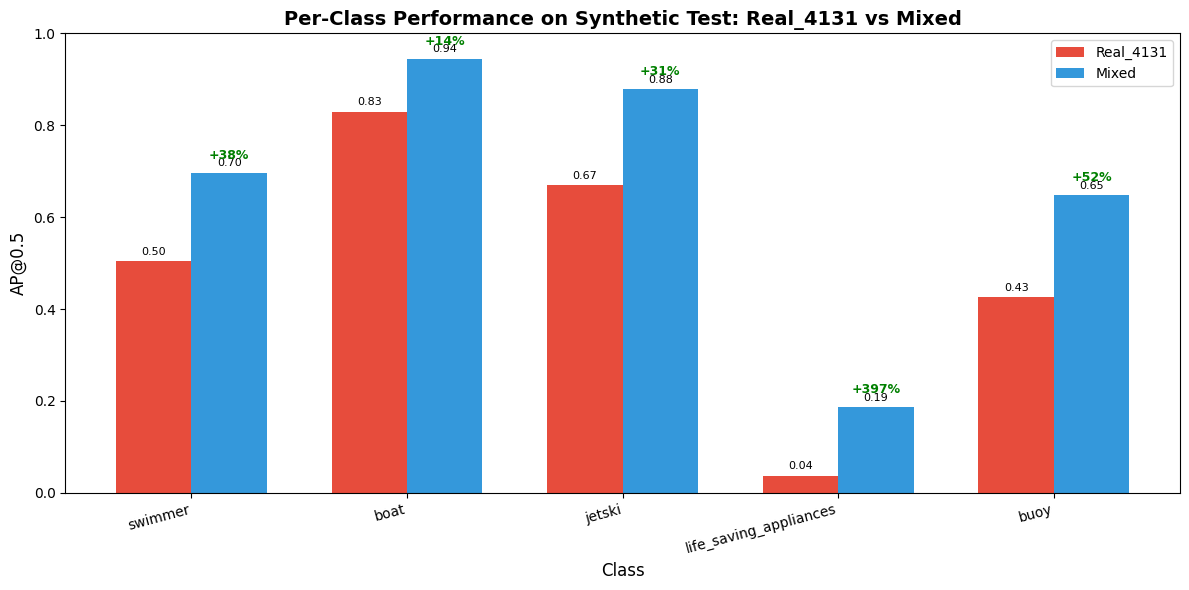


Per-Class Improvement Table:


,Class,Real_4131,Mixed,Improvement,Improvement_Pct
0,swimmer,0.504,0.697,0.193,38.239
1,boat,0.830,0.945,0.115,13.902
2,jetski,0.669,0.879,0.210,31.342
3,life_saving_appliances,0.038,0.187,0.149,397.128
4,buoy,0.426,0.648,0.222,52.237



[OK] Saved to: /content/drive/MyDrive/StormVision/results/metrics/per_class_improvement.png


In [ ]:
# Per-Class Improvement Bar Chart
print("="*80)
print("           PER-CLASS IMPROVEMENT: Mixed vs Real_4131")
print("="*80)

# Calculate per-class improvement on Synthetic test
improvements = []
for cls_name in CLASS_NAMES:
    col = f'AP50_{cls_name}'
    if col in df_results.columns:
        mixed_val = df_results[(df_results['model'] == 'Mixed') & (df_results['test_set'] == 'Synthetic')][col].values
        real_val = df_results[(df_results['model'] == 'Real_4131') & (df_results['test_set'] == 'Synthetic')][col].values

        if len(mixed_val) > 0 and len(real_val) > 0:
            improvement = mixed_val[0] - real_val[0]
            pct_improvement = (improvement / real_val[0]) * 100 if real_val[0] > 0 else 0
            improvements.append({
                'Class': cls_name,
                'Real_4131': real_val[0],
                'Mixed': mixed_val[0],
                'Improvement': improvement,
                'Improvement_Pct': pct_improvement
            })

improvement_df = pd.DataFrame(improvements)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(improvement_df))
width = 0.35

bars1 = ax.bar(x - width/2, improvement_df['Real_4131'], width, label='Real_4131', color='#e74c3c')
bars2 = ax.bar(x + width/2, improvement_df['Mixed'], width, label='Mixed', color='#3498db')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('AP@0.5', fontsize=12)
ax.set_title('Per-Class Performance on Synthetic Test: Real_4131 vs Mixed', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(improvement_df['Class'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)

# Add improvement annotations
for i, row in improvement_df.iterrows():
    ax.annotate(f'+{row["Improvement_Pct"]:.0f}%',
                xy=(i + width/2, row['Mixed'] + 0.03),
                ha='center', fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(METRICS_PATH / 'per_class_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-Class Improvement Table:")
display(improvement_df.round(3))
print(f"\n[OK] Saved to: {METRICS_PATH / 'per_class_improvement.png'}")

## 8. Improvement Analysis

In [ ]:
# Improvement Analysis as DataFrame
print("="*80)
print("       FAIR COMPARISON: Mixed vs Real_4131")
print("       (Both trained on 4131 unique scenes)")
print("="*80)

# Build comparison DataFrame
comparison_data = []

for test_set in ['Real', 'Synthetic', 'Mixed']:
    mixed_row = df_results[(df_results['model'] == 'Mixed') & (df_results['test_set'] == test_set)]
    real_row = df_results[(df_results['model'] == 'Real_4131') & (df_results['test_set'] == test_set)]

    if len(mixed_row) > 0 and len(real_row) > 0:
        mixed_val = mixed_row['mAP50'].values[0]
        real_val = real_row['mAP50'].values[0]
        diff = mixed_val - real_val
        pct = (diff / real_val * 100) if real_val > 0 else 0

        comparison_data.append({
            'Test Set': test_set,
            'Real_4131': real_val,
            'Mixed': mixed_val,
            'Difference': diff,
            'Improvement (%)': pct
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Test Set')

# Format for display
display_df = comparison_df.copy()
display_df['Real_4131'] = display_df['Real_4131'].apply(lambda x: f"{x:.4f}")
display_df['Mixed'] = display_df['Mixed'].apply(lambda x: f"{x:.4f}")
display_df['Difference'] = display_df['Difference'].apply(lambda x: f"+{x:.4f}" if x > 0 else f"{x:.4f}")
display_df['Improvement (%)'] = display_df['Improvement (%)'].apply(lambda x: f"+{x:.1f}%" if x > 0 else f"{x:.1f}%")

print("\nFair Comparison: Mixed vs Real_4131 (mAP@0.5):")
display(display_df)

# Styled version with color gradient
print("\nStyled Version:")
styled = comparison_df[['Real_4131', 'Mixed']].style.background_gradient(cmap='RdYlGn', axis=None, vmin=0.4, vmax=0.8)
display(styled)

       FAIR COMPARISON: Mixed vs Real_4131
       (Both trained on 4131 unique scenes)

Fair Comparison: Mixed vs Real_4131 (mAP@0.5):


,Real_4131,Mixed,Difference,Improvement (%)
Test Set,,,,
Real,0.6873,0.7092,+0.0219,+3.2%
Synthetic,0.4932,0.6711,+0.1779,+36.1%
Mixed,0.5931,0.6895,+0.0964,+16.3%



Styled Version:


,Real_4131,Mixed
Test Set,,
Real,0.687264,0.709154
Synthetic,0.493218,0.671135
Mixed,0.593094,0.689499


In [ ]:
# Improvement over COCO Pretrained as DataFrame
print("\n" + "="*80)
print("       IMPROVEMENT OVER COCO PRETRAINED BASELINE")
print("="*80)

# Build COCO comparison DataFrame
coco_comparison_data = []

for test_set in ['Real', 'Synthetic', 'Mixed']:
    coco_row = df_results[(df_results['model'] == 'COCO_Pretrained') & (df_results['test_set'] == test_set)]
    mixed_row = df_results[(df_results['model'] == 'Mixed') & (df_results['test_set'] == test_set)]

    if len(coco_row) > 0 and len(mixed_row) > 0:
        coco_val = coco_row['mAP50'].values[0]
        mixed_val = mixed_row['mAP50'].values[0]
        gain = mixed_val - coco_val
        multiplier = mixed_val / coco_val if coco_val > 0 else 0

        coco_comparison_data.append({
            'Test Set': test_set,
            'COCO_Pretrained': coco_val,
            'Mixed': mixed_val,
            'Gain': gain,
            'Multiplier': multiplier
        })

coco_df = pd.DataFrame(coco_comparison_data)
coco_df = coco_df.set_index('Test Set')

# Format for display
display_coco_df = coco_df.copy()
display_coco_df['COCO_Pretrained'] = display_coco_df['COCO_Pretrained'].apply(lambda x: f"{x:.4f}")
display_coco_df['Mixed'] = display_coco_df['Mixed'].apply(lambda x: f"{x:.4f}")
display_coco_df['Gain'] = display_coco_df['Gain'].apply(lambda x: f"+{x:.4f}")
display_coco_df['Multiplier'] = display_coco_df['Multiplier'].apply(lambda x: f"x{x:.1f}")

print("\nImprovement over COCO Pretrained (mAP@0.5):")
display(display_coco_df)


       IMPROVEMENT OVER COCO PRETRAINED BASELINE

Improvement over COCO Pretrained (mAP@0.5):


,COCO_Pretrained,Mixed,Gain,Multiplier
Test Set,,,,
Real,0.0731,0.7092,+0.6361,x9.7
Synthetic,0.0664,0.6711,+0.6047,x10.1
Mixed,0.0688,0.6895,+0.6207,x10.0


## 9. Final Summary

In [ ]:
print("\n" + "="*80)
print("                         FINAL SUMMARY")
print("="*80)

# Saved Models DataFrame
print("\n[1] SAVED MODELS:")
models_status = []
for model_name in ['model_real', 'model_real_4131', 'model_mixed']:
    path = WEIGHTS_PATH / model_name / 'weights' / 'best.pt'
    models_status.append({
        'Model': model_name,
        'Path': str(path),
        'Status': 'OK' if path.exists() else 'MISSING'
    })
models_df = pd.DataFrame(models_status)
display(models_df)

# Saved Metrics
print("\n[2] SAVED METRICS:")
metrics_files = [
    METRICS_PATH / 'comprehensive_results.csv',
    METRICS_PATH / 'model_comparison.png',
    METRICS_PATH / 'per_class_heatmap.png',
    METRICS_PATH / 'performance_degradation.png',
    METRICS_PATH / 'per_class_improvement.png'
]
metrics_status = []
for f in metrics_files:
    metrics_status.append({
        'File': f.name,
        'Status': 'OK' if f.exists() else 'NOT SAVED'
    })
metrics_df = pd.DataFrame(metrics_status)
display(metrics_df)

# Key Findings DataFrame
print("\n[3] KEY FINDINGS:")
key_findings = []

for test_set in ['Real', 'Synthetic', 'Mixed']:
    test_results = df_results[df_results['test_set'] == test_set]
    if len(test_results) > 0:
        best_idx = test_results['mAP50'].idxmax()
        best_model = test_results.loc[best_idx, 'model']
        best_score = test_results.loc[best_idx, 'mAP50']
        key_findings.append({
            'Test Set': test_set,
            'Best Model': best_model,
            'mAP@0.5': f"{best_score:.3f}"
        })

findings_df = pd.DataFrame(key_findings)
display(findings_df)

# Robustness Summary
print("\n[4] ROBUSTNESS SUMMARY:")
robustness_summary = []
for model_name in ['Real_8262', 'Real_4131', 'Mixed']:
    real_val = df_results[(df_results['model'] == model_name) & (df_results['test_set'] == 'Real')]['mAP50'].values[0]
    synth_val = df_results[(df_results['model'] == model_name) & (df_results['test_set'] == 'Synthetic')]['mAP50'].values[0]
    deg = ((real_val - synth_val) / real_val) * 100
    robustness_summary.append({
        'Model': model_name,
        'Real mAP50': f"{real_val:.3f}",
        'Synthetic mAP50': f"{synth_val:.3f}",
        'Degradation': f"{deg:.1f}%",
        'Robustness': 'Excellent' if deg < 10 else 'Good' if deg < 20 else 'Poor'
    })
robustness_df = pd.DataFrame(robustness_summary)
display(robustness_df)

print("\n" + "="*80)
print("                    EVALUATION COMPLETE")
print("="*80)


                         FINAL SUMMARY

[1] SAVED MODELS:


,Model,Path,Status
0,model_real,/content/drive/MyDrive/StormVision/results/wei...,OK
1,model_real_4131,/content/drive/MyDrive/StormVision/results/wei...,OK
2,model_mixed,/content/drive/MyDrive/StormVision/results/wei...,OK



[2] SAVED METRICS:


,File,Status
0,comprehensive_results.csv,OK
1,model_comparison.png,OK
2,per_class_heatmap.png,OK
3,performance_degradation.png,OK
4,per_class_improvement.png,OK



[3] KEY FINDINGS:


,Test Set,Best Model,mAP@0.5
0,Real,Mixed,0.709
1,Synthetic,Mixed,0.671
2,Mixed,Mixed,0.689



[4] ROBUSTNESS SUMMARY:


,Model,Real mAP50,Synthetic mAP50,Degradation,Robustness
0,Real_8262,0.708,0.491,30.6%,Poor
1,Real_4131,0.687,0.493,28.2%,Poor
2,Mixed,0.709,0.671,5.4%,Excellent



                    EVALUATION COMPLETE


In [ ]:
# ============================================================
# 10. EXAMPLE PREDICTIONS
# ============================================================
print("="*80)
print("                    EXAMPLE PREDICTIONS")
print("="*80)

from PIL import Image

# Get sample images from synthetic test set
test_images_path = DATA_PATH / 'synthetic' / 'test' / 'images'
sample_images = sorted(list(test_images_path.glob('*.jpg')))[:4]  # Take 4 samples

if len(sample_images) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, img_path in enumerate(sample_images):
        # Run prediction with Mixed model
        results = model_mixed.predict(str(img_path), conf=0.25, verbose=False)
        annotated = results[0].plot()

        axes[i].imshow(annotated)
        axes[i].set_title(f'{img_path.name}', fontsize=11)
        axes[i].axis('off')

    plt.suptitle('Mixed Model Predictions on Synthetic Test Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(METRICS_PATH / 'example_predictions_synthetic.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n[OK] Saved to: {METRICS_PATH / 'example_predictions_synthetic.png'}")
else:
    print("No sample images found!")

Output hidden; open in https://colab.research.google.com to view.


    COMPARISON: Mixed Model on Real vs Synthetic Images


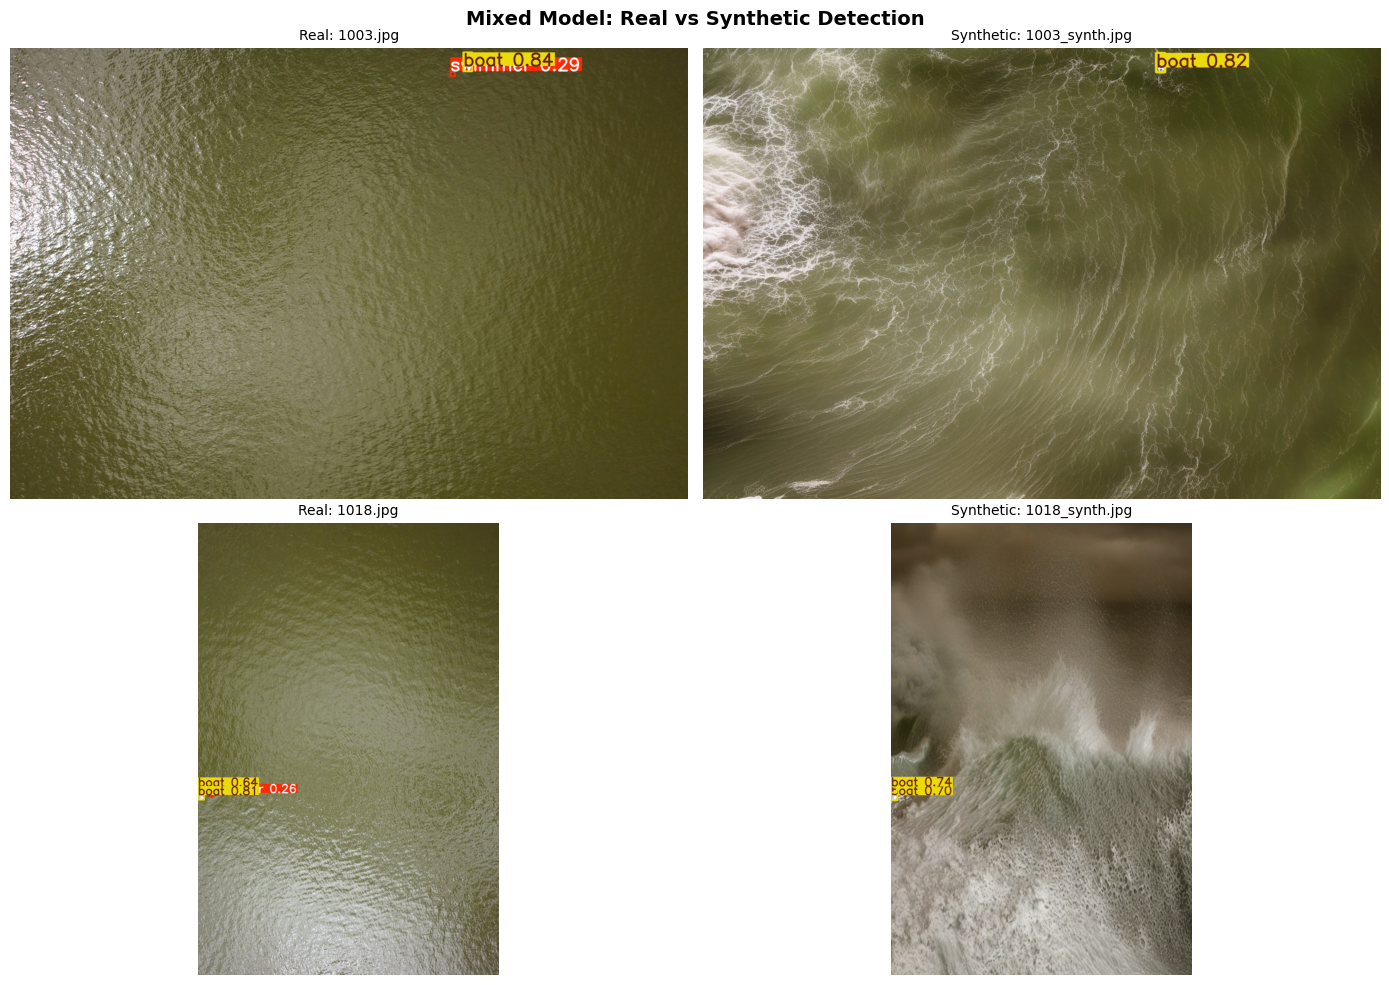


[OK] Saved to: /content/drive/MyDrive/StormVision/results/metrics/real_vs_synthetic_predictions.png


In [ ]:
# COMPARISON: Same model on Real vs Synthetic
print("\n" + "="*80)
print("    COMPARISON: Mixed Model on Real vs Synthetic Images")
print("="*80)

# Get samples from both test sets
real_images_path = DATA_PATH / 'val' / 'images'
synth_images_path = DATA_PATH / 'synthetic' / 'test' / 'images'

real_samples = sorted(list(real_images_path.glob('*.jpg')))[:2]
synth_samples = sorted(list(synth_images_path.glob('*.jpg')))[:2]

if len(real_samples) > 0 and len(synth_samples) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Real images
    for i, img_path in enumerate(real_samples):
        results = model_mixed.predict(str(img_path), conf=0.25, verbose=False)
        annotated = results[0].plot()
        axes[i, 0].imshow(annotated)
        axes[i, 0].set_title(f'Real: {img_path.name}', fontsize=10)
        axes[i, 0].axis('off')

    # Synthetic images
    for i, img_path in enumerate(synth_samples):
        results = model_mixed.predict(str(img_path), conf=0.25, verbose=False)
        annotated = results[0].plot()
        axes[i, 1].imshow(annotated)
        axes[i, 1].set_title(f'Synthetic: {img_path.name}', fontsize=10)
        axes[i, 1].axis('off')

    axes[0, 0].set_ylabel('Sample 1', fontsize=12)
    axes[1, 0].set_ylabel('Sample 2', fontsize=12)

    plt.suptitle('Mixed Model: Real vs Synthetic Detection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(METRICS_PATH / 'real_vs_synthetic_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n[OK] Saved to: {METRICS_PATH / 'real_vs_synthetic_predictions.png'}")